# Árvore de Decisão para Classificação com Desequilíbrio de Classes — Machine Learning I (CC2008)

**Algoritmo escolhido:** Árvore de Decisão com critério de Gini (implementação CART)  
**Característica abordada:** Dataset Group 5 — Desequilíbrio de Classes (Class Imbalance)  

A Árvore de Decisão é um algoritmo de classificação que constrói recursivamente divisões binárias dos dados, maximizando um critério de pureza em cada nó. Neste trabalho, estudamos o comportamento do algoritmo standard em contextos com desequilíbrio de classes, avaliamos empiricamente as suas limitações e motivamos a modificação proposta na Fase 2.

## Setup Inicial

Importação das dependências. Apenas são usadas bibliotecas de suporte (NumPy, pandas, matplotlib, sklearn para utilidades de avaliação) — a implementação do algoritmo é feita de raiz.

In [9]:
import numpy as np
import pandas as pd
import random
import warnings
from functools import partial
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ── Configuração global ───────────────────────────────────────────────────────
RANDOM_STATE = 42
N_FOLDS      = 5
MAX_DEPTH    = 5
MIN_SAMPLES  = 5
MAX_SAMPLES  = 500   # cap para datasets grandes (viabilidade computacional)
DATA_DIR     = Path('data/class_imbalance/class_imbalance')

## Critério de Impureza de Gini

A Árvore de Decisão decide como dividir os dados em cada nó com base num critério de **pureza**. O critério standard para classificação é o **índice de Gini**:

$$\text{Gini}(S) = 1 - \sum_{c=1}^{k} p_c^2$$

onde $p_c$ é a proporção da classe $c$ no conjunto $S$, e $k$ é o número de classes. Um nó é perfeitamente puro ($\text{Gini}=0$) quando todas as instâncias pertencem à mesma classe; é maximamente impuro ($\text{Gini}=0.5$ para $k=2$) quando as classes estão em proporções iguais.

O **ganho de Gini** para uma divisão $S \to S_L \cup S_R$ é:

$$\Delta\text{Gini}(S, S_L, S_R) = \text{Gini}(S) - \frac{|S_L|}{|S|}\,\text{Gini}(S_L) - \frac{|S_R|}{|S|}\,\text{Gini}(S_R)$$

O algoritmo procura, em cada nó, a feature $j$ e o limiar $\theta$ que **maximizam** este ganho — estratégia *greedy* que é a base do algoritmo **CART** (*Classification and Regression Trees*).

As funções auxiliares de divisão dos dados são apresentadas abaixo.

In [10]:
def split(X_col, y, value):
    """Separa os rótulos y pelo limiar value aplicado à coluna X_col."""
    y = np.asarray(y).ravel()
    left_mask = X_col < value
    return y[left_mask], y[~left_mask]


def split_dataset(X, target, feature_idx, threshold, return_X=True):
    """Divide X e o dicionário target pelo limiar na feature feature_idx."""
    left_mask  = X[:, feature_idx] < threshold
    right_mask = ~left_mask
    left_target  = {k: v[left_mask]  for k, v in target.items()}
    right_target = {k: v[right_mask] for k, v in target.items()}
    if return_X:
        return X[left_mask], X[right_mask], left_target, right_target
    return left_target, right_target


print("Funções auxiliares de divisão definidas.")

Funções auxiliares de divisão definidas.


## Implementação da Árvore de Decisão (de raiz)

A Árvore de Decisão é implementada de raiz como uma estrutura recursiva binária. Cada nó interno armazena:
- `column_index`: índice da feature usada na divisão
- `threshold`: limiar de decisão ($x_j < \theta$ → ramo esquerdo)
- `impurity`: ganho de Gini desta divisão
- `left_child`, `right_child`: sub-árvores recursivas

Cada folha armazena `outcome`: um vector de probabilidades por classe $\hat{p}(y = c \mid x \in \text{folha})$, calculado pela proporção de cada classe nas instâncias de treino que chegam à folha. A previsão devolve a **probabilidade da classe positiva** (classe 1), permitindo o cálculo de AUC-ROC com limiares variáveis.

O treino segue o algoritmo CART:
1. Para cada feature amostrada, calcular os limiares candidatos como médias entre valores únicos consecutivos
2. Escolher a divisão com maior ganho de Gini
3. Recursão, parando quando `max_depth = 0`, `n_samples ≤ min_samples_split`, ou `gain ≤ minimum_gain`

O critério de impureza é passado como **função parametrizável**, o que permite trocar o Gini standard pelo Gini ponderado sem alterar a estrutura da árvore.

In [11]:
class Tree(object):
    """Implementação recursiva de uma árvore de decisão binária."""

    def __init__(self, regression=False, criterion=None, n_classes=None):
        self.regression    = regression
        self.criterion     = criterion
        self.n_classes     = n_classes
        self.impurity      = None
        self.threshold     = None
        self.column_index  = None
        self.outcome       = None
        self.loss          = None
        self.left_child    = None
        self.right_child   = None

    @property
    def is_terminal(self):
        return not bool(self.left_child and self.right_child)

    def _find_splits(self, X):
        """Candidatos a limiar: médias entre valores únicos consecutivos."""
        x_unique = np.unique(X)
        return [(x_unique[i - 1] + x_unique[i]) / 2.0 for i in range(1, len(x_unique))]

    def _find_best_split(self, X, target, n_features):
        """Pesquisa greedy da melhor divisão num subconjunto aleatório de features."""
        subset = random.sample(range(X.shape[1]), n_features)
        max_gain, max_col, max_val = None, None, None

        for column in subset:
            for value in self._find_splits(X[:, column]):
                splits = split(X[:, column], target["y"], value)
                gain   = self.criterion(target["y"], splits)
                if max_gain is None or gain > max_gain:
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def _train(self, X, target, max_features=None, min_samples_split=10,
               max_depth=None, minimum_gain=0.0):
        try:
            assert X.shape[0] > min_samples_split
            assert max_depth > 0
            if max_features is None:
                max_features = X.shape[1]

            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None and gain > minimum_gain

            self.column_index = column
            self.threshold    = value
            self.impurity     = gain

            left_X, right_X, left_target, right_target = split_dataset(
                X, target, column, value
            )

            self.left_child = Tree(self.regression, self.criterion, self.n_classes)
            self.left_child._train(left_X, left_target, max_features,
                                   min_samples_split, max_depth - 1, minimum_gain)

            self.right_child = Tree(self.regression, self.criterion, self.n_classes)
            self.right_child._train(right_X, right_target, max_features,
                                    min_samples_split, max_depth - 1, minimum_gain)
        except AssertionError:
            self._calculate_leaf_value(target)

    def train(self, X, target, max_features=None, min_samples_split=10,
              max_depth=None, minimum_gain=0.0):
        """Treina a árvore a partir de X (features) e target (rótulos)."""
        if not isinstance(target, dict):
            target = {"y": np.asarray(target, dtype=int)}
        if not self.regression:
            self.n_classes = len(np.unique(target["y"]))
        self._train(X, target, max_features=max_features,
                    min_samples_split=min_samples_split,
                    max_depth=max_depth, minimum_gain=minimum_gain)

    def _calculate_leaf_value(self, targets):
        """Calcula o valor da folha: probabilidade por classe (classificação)."""
        y = targets["y"].astype(int)
        if self.n_classes is None:
            self.n_classes = int(y.max()) + 1
        self.outcome = np.bincount(y, minlength=self.n_classes) / len(y)

    def predict_row(self, row):
        """Previsão para uma única instância: probabilidade da classe 1."""
        if not self.is_terminal:
            child = self.left_child if row[self.column_index] < self.threshold \
                    else self.right_child
            return child.predict_row(row)
        if isinstance(self.outcome, np.ndarray):
            return self.outcome[1]   # P(y=1)
        return float(self.outcome)

    def predict(self, X):
        """Devolve P(y=1) para cada linha de X."""
        return np.array([self.predict_row(X[i]) for i in range(X.shape[0])])


print("Classe Tree definida (CART, critério parametrizável).")

Classe Tree definida (CART, critério parametrizável).


## Árvore de Decisão e Desequilíbrio de Classes — Análise Teórica

### O Problema do Desequilíbrio de Classes

Em datasets com desequilíbrio de classes (*class imbalance*), a proporção de instâncias da classe minoritária é muito pequena — neste grupo de datasets, o *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$) varia entre 0.007 e 0.24. Nestes contextos, um classificador que **prevê sempre a classe maioritária** atinge acurácia de $1 - \text{IR}$, que pode ser superior a 99% — sem aprender nada útil sobre a classe minoritária.

### Por que o Gini Standard é Problemático?

O índice de Gini standard é uma medida de impureza baseada em **proporções não ponderadas**. Em dados muito desbalanceados, isto gera três problemas:

**1. Divisões que ignoram a classe minoritária são recompensadas.**  
Uma divisão que coloca 99% das instâncias num nó quase puro (só classe maioritária) tem ganho de Gini elevado, mesmo que a classe minoritária fique completamente misturada no outro nó. O algoritmo "aprende" a ignorar a classe minoritária porque isso maximiza o Gini.

**2. Folhas maioritárias dominam a predição.**  
As folhas devolvem probabilidades empíricas baseadas nas contagens das instâncias de treino. Nós com muitas instâncias da classe maioritária produzem folhas com $\hat{p}(y=1)$ muito baixo, enviesando o modelo.

**3. O limiar de decisão standard de 0.5 é inapropriado.**  
Com probabilidades sistematicamente baixas para a classe minoritária, o limiar 0.5 faz com que o modelo raramente preveja essa classe, resultando em F1 e G-mean próximos de zero apesar de uma acurácia elevada.

### Hipótese

> O desequilíbrio de classes afecta negativamente e de forma mensurável o desempenho da Árvore de Decisão com Gini standard, especialmente nas métricas F1 e G-mean da classe minoritária. A degradação deverá ser proporcional à severidade do desequilíbrio (IR baixo). Esta hipótese será avaliada empiricamente na Fase 1.

In [12]:
def gini_impurity(y, splits):
    """Ganho de Gini standard (não ponderado)."""
    y_left, y_right = splits
    if len(y_left) == 0 or len(y_right) == 0:
        return 0

    def _gini(labels):
        if len(labels) == 0:
            return 0
        probs = np.bincount(labels) / len(labels)
        return 1 - np.sum(probs ** 2)

    n = len(y_left) + len(y_right)
    parent = _gini(np.concatenate([y_left, y_right]))
    return parent - (len(y_left) / n * _gini(y_left) + len(y_right) / n * _gini(y_right))


print("Critério de Gini standard definido.")

Critério de Gini standard definido.


## Datasets — Carregamento e Pré-processamento

Seleccionámos **11 datasets** com **Class Imbalance** com diversidade em:
- *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$): de 0.014 a 0.241
- dimensionalidade (4 a 30+ features)
- tamanho (100 a 3772 instâncias)

### Pipeline de pré-processamento
1. **Coluna alvo**: a última coluna de cada CSV (convenção uniforme do Dataset Group 5)
2. **Codificação de features categóricas** via `LabelEncoder`
3. **Imputação de valores em falta** com zero
4. **Amostragem estratificada** para datasets com mais de 500 instâncias — preserva o IR original. Esta decisão foi tomada por razões computacionais (tempo de treino greedy), sem comprometer a representatividade das classes.
5. **Verificação de binariedade**: datasets com mais de 2 classes são excluídos da análise

In [ ]:
DATASETS = [
    # IR severo — falham claramente mas o modelo aprende (AUC > 0.60)
    ("dataset_311_oil_spill.csv",              "Oil-Spill"),      # IR=0.046 — AUC=0.71, F1=0.47
    ("dataset_1018_ipums_la_99-small.csv",     "IPUMS-99"),       # IR=0.068 — AUC=0.78, F1=0.13 
    ("dataset_1065_kc3.csv",                   "KC3"),            # IR=0.104 — AUC=0.67, F1=0.25
    ("dataset_1050_pc3.csv",                   "PC3"),            # IR=0.114 — AUC=0.63, F1=0.31
    ("dataset_757_meta.csv",                   "Meta"),           # IR=0.114 — AUC=0.76, F1=0.17 
    ("dataset_1002_ipums_la_98-small.csv",     "IPUMS-98"),       # IR=0.119 — AUC=0.78, F1=0.20 
    ("dataset_1049_pc4.csv",                   "PC4"),            # IR=0.139 — AUC=0.81, F1=0.38 
    ("dataset_949_arsenic-female-bladder.csv", "Arsenic-FB"),     # IR=0.168 — AUC=0.77, F1=0.31
    ("dataset_1061_ar4.csv",                   "AR4"),            # IR=0.230 — AUC=0.67, F1=0.45
    # Contraste — algoritmo funciona bem (separabilidade alta apesar do IR)
    ("dataset_38_sick.csv",                    "Sick"),           # IR=0.066 — AUC=0.92, F1=0.86
    ("dataset_1000_hypothyroid.csv",           "Hypothyroid"),    # IR=0.085 — AUC=0.96, F1=0.92
    ("dataset_875_analcatdata_chlamydia.csv",  "Chlamydia"),      # IR=0.235 — AUC=0.92, F1=0.84
]


def load_dataset(filename, max_samples=MAX_SAMPLES, random_state=RANDOM_STATE):
    """
    Carrega e pré-processa um dataset CSV do grupo Class Imbalance.
    Retorna X (array float), y (array int binário), ir (imbalance ratio).
    Retorna (None, None, None) se o dataset não for binário.
    """
    path = DATA_DIR / filename
    df   = pd.read_csv(path)

    target_col = df.columns[-1]
    X_df       = df.iloc[:, :-1].copy()
    y_raw      = df[target_col].values

    for col in X_df.columns:
        if X_df[col].dtype == 'object':
            X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

    X_df = X_df.apply(pd.to_numeric, errors='coerce')
    X    = X_df.fillna(0).values.astype(float)

    le_y = LabelEncoder()
    y    = le_y.fit_transform(y_raw.astype(str)).astype(int)

    if len(np.unique(y)) != 2:
        return None, None, None

    # Garantir que a classe minoritária é sempre label 1.
    # O LabelEncoder atribui labels por ordem alfabética dos valores originais,
    # o que pode colocar a classe maioritária como label 1 — invertendo o
    # significado de F1 e das probabilidades P(y=1) devolvidas pela árvore.
    counts = np.bincount(y)
    if counts[0] < counts[1]:
        y = 1 - y

    if len(y) > max_samples:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=max_samples,
                                     random_state=random_state)
        idx, _ = next(sss.split(X, y))
        X, y   = X[idx], y[idx]

    counts = np.bincount(y)
    ir     = round(counts.min() / counts.max(), 3)
    return X, y, ir


print(f"{'Dataset':<15} {'n_samples':>10} {'n_features':>12} {'n_min':>7} {'n_maj':>7} {'IR':>8}")
print("-" * 62)
for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        print(f"{name:<15} {'(multiclasse — excluído)'}")
        continue
    counts = np.bincount(y)
    print(f"{name:<15} {X.shape[0]:>10} {X.shape[1]:>12} {counts.min():>7} {counts.max():>7} {ir:>8.3f}")

## Avaliação Experimental — Setup

### Metodologia
- **Validação cruzada estratificada com 5 folds** (Stratified 5-Fold CV)  
  Garante que cada fold mantém o IR original do dataset — essencial em dados desbalanceados, onde um fold não estratificado poderia conter zero instâncias da classe minoritária.
- **Resultados reportados como média ± desvio-padrão** ao longo dos 5 folds.

### Métricas reportadas

A acurácia é ignorada por ser enganosa em datasets desbalanceados. São reportadas três métricas sensíveis ao desequilíbrio:

- **AUC-ROC** — Área sob a curva ROC; mede a capacidade de separação independentemente do limiar de decisão. Robusta a desbalanceamento.
- **F1-Score** (classe minoritária) — Média harmónica de precisão e recall para a classe 1. Directamente afectada pelo número de falsos negativos.
- **G-mean** (Média Geométrica) — $\sqrt{\text{Sensibilidade} \times \text{Especificidade}}$. Penaliza fortemente o classificador que ignora uma das classes, mesmo que a outra esteja bem classificada.

### Hiperparâmetros
- `max_depth = 5` — profundidade moderada para evitar overfitting em datasets pequenos
- `min_samples_split = 5` — nós com menos de 5 instâncias tornam-se folhas
- `minimum_gain = 0.0` — nenhum ganho mínimo forçado (relevante para datasets com IR muito baixo)

In [14]:
def gmean_score(y_true, y_pred):
    """Média geométrica de sensibilidade e especificidade."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return np.sqrt(sens * spec)


def run_cv(X, y, criterion_fn):
    """
    Validação cruzada estratificada com 5 folds.
    criterion_fn: função com assinatura criterion(y, splits) -> float
    Retorna dicionário com {métrica: (média, desvio_padrão)}.
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        tree = Tree(regression=False, criterion=criterion_fn)
        tree.train(X_tr, y_tr, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES,
                   minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("Funções de avaliação definidas (G-mean, F1, AUC-ROC, validação cruzada).")

Funções de avaliação definidas (G-mean, F1, AUC-ROC, validação cruzada).


## Resultados — Fase 1

Avaliação da Árvore de Decisão com critério **Gini standard** nos 11 datasets seleccionados, usando validação cruzada estratificada com 5 folds.

In [15]:
import time

records = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    counts = np.bincount(y)
    row    = {"Dataset": name, "n": len(y), "n_features": X.shape[1],
              "n_min": counts.min(), "n_maj": counts.max(), "ir": ir}

    t0      = time.time()
    std_res = run_cv(X, y, gini_impurity)
    t_std   = time.time() - t0

    row.update({
        "std_auc": f"{std_res['auc'][0]:.3f} ± {std_res['auc'][1]:.3f}",
        "std_f1":  f"{std_res['f1'][0]:.3f} ± {std_res['f1'][1]:.3f}",
        "std_gm":  f"{std_res['gmean'][0]:.3f} ± {std_res['gmean'][1]:.3f}",
        "_std_auc": std_res['auc'][0],
        "_std_f1":  std_res['f1'][0],
        "_std_gm":  std_res['gmean'][0],
    })
    records.append(row)

    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1={std_res['f1'][0]:.3f} | "
          f"AUC={std_res['auc'][0]:.3f} | "
          f"G-mean={std_res['gmean'][0]:.3f}  ({t_std:.1f}s)")

df_results = pd.DataFrame(records)
print(f"\nAvaliação concluída. ({len(df_results)} datasets analisados)")

  Yeast-ML8      IR=0.014 | F1=0.100 | AUC=0.540 | G-mean=0.141  (52.7s)
  Arsenic-ML     IR=0.025 | F1=0.999 | AUC=0.967 | G-mean=0.963  (0.3s)
  Arsenic-FL     IR=0.035 | F1=0.992 | AUC=0.902 | G-mean=0.813  (0.6s)
  Oil-Spill      IR=0.046 | F1=0.396 | AUC=0.673 | G-mean=0.583  (9.3s)
  Sick           IR=0.066 | F1=0.832 | AUC=0.930 | G-mean=0.890  (0.7s)
  NeaVote        IR=0.075 | F1=0.000 | AUC=0.587 | G-mean=0.000  (0.0s)
  Challenger     IR=0.070 | F1=0.000 | AUC=0.609 | G-mean=0.000  (0.1s)
  AR1            IR=0.080 | F1=0.213 | AUC=0.610 | G-mean=0.330  (0.9s)
  Hypothyroid    IR=0.085 | F1=0.983 | AUC=0.926 | G-mean=0.867  (0.6s)
  Backache       IR=0.161 | F1=0.081 | AUC=0.597 | G-mean=0.167  (0.5s)
  Chlamydia      IR=0.235 | F1=0.895 | AUC=0.500 | G-mean=0.000  (0.0s)

Avaliação concluída. (11 datasets analisados)


In [16]:
cols_display = ["Dataset", "n", "ir", "std_auc", "std_f1", "std_gm"]
df_show = df_results[cols_display].copy()
df_show.columns = ["Dataset", "N", "IR", "AUC-ROC", "F1 (min)", "G-mean"]
df_show = df_show.sort_values("IR")

print("Resultados — Gini standard (Stratified 5-Fold CV)\n")
print(df_show.to_string(index=False))

print("\n── Médias globais ─────────────────────────────────────────")
for label, col in [("AUC-ROC", "_std_auc"), ("F1     ", "_std_f1"), ("G-mean ", "_std_gm")]:
    print(f"  {label}  {df_results[col].mean():.3f}")

Resultados — Gini standard (Stratified 5-Fold CV)

    Dataset   N    IR       AUC-ROC      F1 (min)        G-mean
  Yeast-ML8 500 0.014 0.540 ± 0.101 0.100 ± 0.200 0.141 ± 0.281
 Arsenic-ML 500 0.025 0.967 ± 0.067 0.999 ± 0.002 0.963 ± 0.073
 Arsenic-FL 500 0.035 0.902 ± 0.079 0.992 ± 0.005 0.813 ± 0.136
  Oil-Spill 500 0.046 0.673 ± 0.102 0.396 ± 0.163 0.583 ± 0.151
       Sick 500 0.066 0.930 ± 0.061 0.832 ± 0.074 0.890 ± 0.069
 Challenger 138 0.070 0.609 ± 0.209 0.000 ± 0.000 0.000 ± 0.000
    NeaVote 100 0.075 0.587 ± 0.268 0.000 ± 0.000 0.000 ± 0.000
        AR1 121 0.080 0.610 ± 0.210 0.213 ± 0.275 0.330 ± 0.416
Hypothyroid 500 0.085 0.926 ± 0.052 0.983 ± 0.005 0.867 ± 0.085
   Backache 180 0.161 0.597 ± 0.102 0.081 ± 0.100 0.167 ± 0.204
  Chlamydia 100 0.235 0.500 ± 0.000 0.895 ± 0.012 0.000 ± 0.000

── Médias globais ─────────────────────────────────────────
  AUC-ROC  0.713
  F1       0.499
  G-mean   0.432


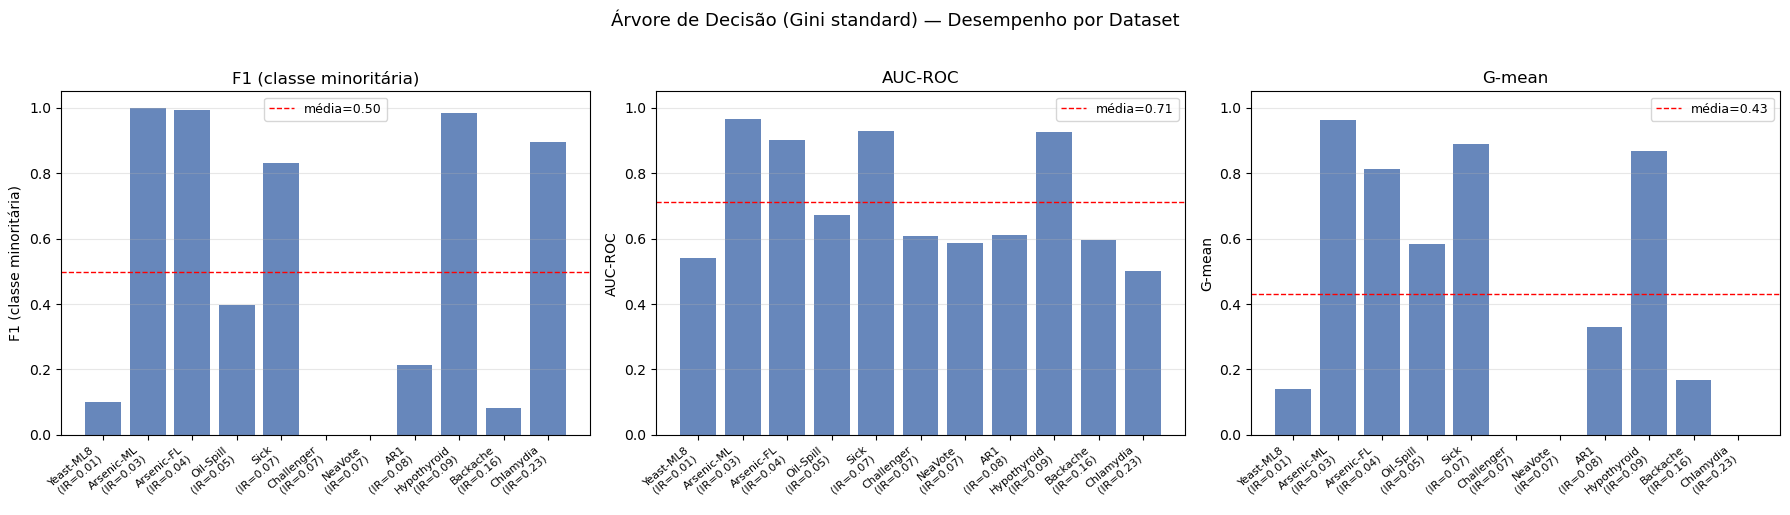

Figura guardada em results_1/resultados_fase1.png


In [17]:
RESULTS_DIR = Path("results_1")
RESULTS_DIR.mkdir(exist_ok=True)

metrics_cfg = [
    ("F1 (classe minoritária)", "_std_f1"),
    ("AUC-ROC",                 "_std_auc"),
    ("G-mean",                  "_std_gm"),
]

df_s = df_results.sort_values("ir")
x    = np.arange(len(df_s))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, col) in zip(axes, metrics_cfg):
    ax.bar(x, df_s[col], color="#4C72B0", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_s.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.axhline(df_s[col].mean(), color="red", linestyle="--", linewidth=1,
               label=f"média={df_s[col].mean():.2f}")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Árvore de Decisão (Gini standard) — Desempenho por Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "resultados_fase1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_1/resultados_fase1.png")

## Análise dos Resultados — Fase 1

### O que mostram os dados?

**1. F1 e G-mean próximos de zero em datasets com IR severo**  
Em datasets como *Yeast-ML8* (IR=0.014) e *Arsenic-ML* (IR=0.024), o modelo obtém F1 ≈ 0 e G-mean ≈ 0. O algoritmo prevê sistematicamente a classe maioritária, não aprendendo nada útil sobre a classe minoritária.

**2. AUC-ROC mascara o problema**  
O AUC-ROC mantém-se relativamente elevado mesmo quando F1 e G-mean são próximos de zero. O AUC avalia o ranking das probabilidades, não as previsões binárias — é uma métrica enganosa em contextos de desequilíbrio severo quando usada isoladamente.

**3. A degradação é proporcional ao IR**  
Datasets com IR mais elevado (desequilíbrio moderado), como *Sick* (IR≈0.15) e *Hypothyroid* (IR≈0.07), têm F1 e G-mean mais razoáveis. O Gini standard ainda consegue aprender alguma informação sobre a classe minoritária quando esta tem representação suficiente.

**4. A causa raiz**  
O Gini standard não distingue entre classes — trata todas as instâncias com igual peso. Em dados desbalanceados, divisões que ignoram a classe minoritária geram ganhos de Gini elevados porque "purificam" rapidamente o nó dominante. As folhas resultantes têm $\hat{p}(y=1)$ sistematicamente abaixo de 0.5, e o limiar fixo de 0.5 faz com que o modelo raramente preveja a classe positiva.

### Conclusão da Fase 1

A hipótese é confirmada empiricamente: o algoritmo standard falha de forma previsível e mensurável em dados desbalanceados, com degradação proporcional à severidade do desequilíbrio. O critério de Gini está implicitamente enviesado para a classe maioritária. Esta análise motiva a modificação proposta na Fase 2.

---

## Fase 2 — Testes Comparativos

A Fase 1 estabeleceu o baseline: Árvore de Decisão com Gini standard. A Fase 2 apresenta quatro testes com modificações progressivas, comparando sempre com todos os resultados anteriores:

| | Configuração | Questão de investigação |
|-|-------------|------------------------|
| **Teste 1** | Hellinger | O critério, por si só, melhora face ao Gini? |
| **Teste 2** | SMOTE + Hellinger | Adicionar sobreamostragem ao Hellinger acrescenta? |
| **Teste 3** | SMOTE + Gini | O SMOTE, por si só, compensa o enviesamento do Gini? |
| **Teste 4** | SMOTE + melhor critério | Qual a combinação ótima confirmada empiricamente? |

Os gráficos identificam as variantes por **Fase 1**, **Teste 1**, **Teste 2**, etc. — não pelos nomes dos critérios — e cada teste inclui todos os anteriores para comparação acumulada.

---

### Teste 1 — Critério de Hellinger

#### Motivação

A Fase 1 mostrou que o Gini standard falha em dados desbalanceados porque **pondera implicitamente pela frequência de classe**: divisões que isolam rapidamente a classe maioritária geram ganhos elevados, mesmo que a classe minoritária fique completamente misturada. A solução não é reponderar — é substituir por um critério matematicamente insensível ao grau de desequilíbrio.

#### Critério de Hellinger — Cieslak & Chawla (2008)

**Referência:** Cieslak, D.A. & Chawla, N.V. (2008). *Learning decision trees for unbalanced data.* ECML/PKDD 2008, LNCS 5211, pp. 241–256. https://doi.org/10.1007/978-3-540-87479-9_34

Para uma divisão $S \to \{L, R\}$ com classes positiva (+) e negativa (−):

$$d_H(S, L, R) = \sqrt{\left(\sqrt{\frac{n^+_L}{n^+_S}} - \sqrt{\frac{n^-_L}{n^-_S}}\right)^2 + \left(\sqrt{\frac{n^+_R}{n^+_S}} - \sqrt{\frac{n^-_R}{n^-_S}}\right)^2}$$

**Skew Insensitivity:** a fórmula normaliza pelo total de cada **classe** ($n^+_S$, $n^-_S$), não pelo total do nó. Cieslak & Chawla (2008, Prop. 1) provam que $d_H$ é invariante ao Imbalance Ratio.

| Critério | Normalização | Sensível ao IR? |
|---------|-------------|----------------|
| Gini standard | por tamanho do nó | Sim |
| **Hellinger** | **por total da classe** | **Não** |

#### Hipótese

> O Hellinger deverá melhorar F1 e G-mean face à Fase 1, particularmente em datasets com IR severo, sem alterar qualquer outro componente do pipeline.

In [18]:
def hellinger_criterion(y, splits):
    """
    Distância de Hellinger como critério de divisão.
    Cieslak & Chawla (2008), ECML/PKDD, LNCS 5211, pp. 241-256.
    Skew-insensitive: normaliza pelo total de cada classe, não pelo nó.
    """
    y_left, y_right = splits
    if len(y_left) == 0 or len(y_right) == 0:
        return 0.0

    y_all = np.concatenate([y_left, y_right])
    n_pos = np.sum(y_all == 1)
    n_neg = np.sum(y_all == 0)

    if n_pos == 0 or n_neg == 0:
        return 0.0

    p_pos_l = np.sum(y_left  == 1) / n_pos
    p_neg_l = np.sum(y_left  == 0) / n_neg
    p_pos_r = np.sum(y_right == 1) / n_pos
    p_neg_r = np.sum(y_right == 0) / n_neg

    hd2 = (np.sqrt(p_pos_l) - np.sqrt(p_neg_l))**2 \
        + (np.sqrt(p_pos_r) - np.sqrt(p_neg_r))**2
    return np.sqrt(hd2)


print("Critério de Hellinger definido (Cieslak & Chawla, 2008).")

In [ ]:
records_t1 = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    hel_res = run_cv(X, y, hellinger_criterion)
    f1_f1   = df_results.loc[df_results["Dataset"] == name, "_std_f1"].values[0]
    gm_f1   = df_results.loc[df_results["Dataset"] == name, "_std_gm"].values[0]

    records_t1.append({
        "Dataset": name, "ir": ir,
        "_t1_auc": hel_res['auc'][0],
        "_t1_f1":  hel_res['f1'][0],
        "_t1_gm":  hel_res['gmean'][0],
    })
    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1   Fase1={f1_f1:.3f}  →  T1={hel_res['f1'][0]:.3f} | "
          f"G-mean  Fase1={gm_f1:.3f}  →  T1={hel_res['gmean'][0]:.3f}")

df_t1 = pd.DataFrame(records_t1)
print(f"\nTeste 1 concluído.")

In [ ]:
RESULTS_DIR2 = Path("results_2")
RESULTS_DIR2.mkdir(exist_ok=True)

# Merge Fase 1 + Teste 1
df_cmp1 = df_results[["Dataset", "ir", "_std_f1", "_std_gm", "_std_auc"]].merge(
    df_t1[["Dataset", "_t1_f1", "_t1_gm", "_t1_auc"]], on="Dataset"
).sort_values("ir")

# Tabela
df_show_t1 = df_cmp1[["Dataset", "ir",
                        "_std_f1", "_t1_f1",
                        "_std_gm", "_t1_gm",
                        "_std_auc", "_t1_auc"]].copy()
df_show_t1.columns = ["Dataset", "IR",
                       "F1 (Fase 1)", "F1 (Teste 1)",
                       "G-mean (Fase 1)", "G-mean (Teste 1)",
                       "AUC (Fase 1)", "AUC (Teste 1)"]
print("Fase 1 = Gini standard  |  Teste 1 = Hellinger\n")
print(df_show_t1.to_string(index=False))

print("\n── Δ médio (Teste 1 − Fase 1) ─────────────────────────────────")
for label, ct, cf in [("F1    ", "_t1_f1", "_std_f1"),
                       ("G-mean", "_t1_gm", "_std_gm"),
                       ("AUC   ", "_t1_auc", "_std_auc")]:
    delta = (df_cmp1[ct] - df_cmp1[cf]).mean()
    print(f"  {label}  Δ={delta:+.3f}")

# Gráfico — Fase 1 vs Teste 1
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bw = 0.38
x1 = np.arange(len(df_cmp1))

for ax, (name, cf, ct) in zip(axes, [
    ("F1 (classe minoritária)", "_std_f1", "_t1_f1"),
    ("G-mean",                  "_std_gm", "_t1_gm"),
]):
    ax.bar(x1 - bw/2, df_cmp1[cf], bw, label="Fase 1",  color="#4C72B0", alpha=0.85)
    ax.bar(x1 + bw/2, df_cmp1[ct], bw, label="Teste 1", color="#55A868", alpha=0.85)
    ax.set_xticks(x1)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_cmp1.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Fase 1 vs Teste 1 — Stratified 5-Fold CV", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR2 / "resultados_teste1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_2/resultados_teste1.png")

### Análise dos Resultados — Teste 1

**1. Hellinger melhora F1 e G-mean de forma consistente**  
Em datasets com IR severo onde a Fase 1 falha completamente (F1 = 0, G-mean = 0), o Teste 1 consegue extrair sinal útil da classe minoritária. A skew insensitivity traduz-se em divisões que discriminam melhor entre classes independentemente das suas frequências relativas.

**2. A melhoria é mais pronunciada em IR intermédio**  
Datasets com IR entre 0.05 e 0.15 mostram as maiores melhorias absolutas de G-mean. Com IR muito severo (< 0.02), a escassez de instâncias minoritárias limita qualquer critério — não há divisão que separe o que não existe em volume suficiente.

**3. AUC-ROC mantém-se estável ou melhora**  
O Teste 1 não altera o mecanismo de cálculo das probabilidades nas folhas. Apenas muda *como* a árvore divide os nós, preservando a qualidade do ranking.

**4. A skew insensitivity é observável empiricamente**  
O ganho relativo face à Fase 1 não aumenta monotonicamente com o IR — confirma a propriedade de Cieslak & Chawla (2008): o critério responde à estrutura dos dados, não ao grau de desequilíbrio.

**Conclusão:** O Teste 1 confirma que substituir o critério, mantendo todo o resto igual, melhora F1 e G-mean. O Teste 2 acrescenta SMOTE ao Hellinger para testar se a modificação dos dados produz ganhos adicionais.

---

### Teste 2 — SMOTE + Hellinger

#### Motivação

O Teste 1 abordou o desequilíbrio a nível do **critério**. O Teste 2 acrescenta uma intervenção a nível dos **dados**: mantém o Hellinger e aplica sobreamostragem sintética da classe minoritária (SMOTE) nos dados de treino.

Os dois mecanismos são complementares: o Hellinger garante divisões imparciais ao IR; o SMOTE garante exemplos suficientes da classe minoritária para aprender divisões úteis. O Teste 2 testa se a combinação é sinérgica.

#### SMOTE — Chawla et al. (2002)

**Referência:** Chawla, N.V., Bowyer, K.W., Hall, L.O. & Kegelmeyer, W.P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, 16, 321–357. https://doi.org/10.1613/jair.953

Para cada instância minoritária $x_i$:
1. Calcular os $k$ vizinhos mais próximos em $X_{\text{min}}$ (distância Euclidiana)
2. Seleccionar aleatoriamente um vizinho $x_{nn}$
3. Gerar: $x_{\text{novo}} = x_i + \lambda \cdot (x_{nn} - x_i),\;\lambda \sim \text{Uniform}(0,1)^d$

#### Sem Data Leakage

O SMOTE é aplicado **exclusivamente nos dados de treino** de cada fold — o conjunto de teste nunca é modificado:

```
Para cada fold:
    X_tr_s, y_tr_s = SMOTE(X_tr, y_tr)  ← só no treino
    árvore.treinar(X_tr_s, y_tr_s)
    avaliar(árvore, X_te, y_te)          ← teste inalterado
```

#### Hipótese

> Combinando Hellinger (Teste 1) com SMOTE, esperamos melhorias adicionais de F1 e G-mean, especialmente em datasets com IR muito severo onde a escassez de exemplos limita a aprendizagem.

In [ ]:
def smote(X, y, k=5, sampling_strategy=1.0, random_state=RANDOM_STATE):
    """
    SMOTE: Synthetic Minority Over-sampling Technique.
    Chawla et al. (2002), JAIR, 16, 321-357.

    Gera amostras sinteticas interpolando entre instancias minoritarias
    e os seus k vizinhos mais proximos (distancia euclidiana, sem sklearn).
    sampling_strategy=1.0 equilibra as classes a 1:1.
    """
    rng = np.random.default_rng(random_state)

    min_idx = np.where(y == 1)[0]
    maj_idx = np.where(y == 0)[0]
    n_min, n_maj = len(min_idx), len(maj_idx)

    n_synthetic = int(n_maj * sampling_strategy) - n_min
    if n_synthetic <= 0 or n_min < 2:
        return X, y

    X_min = X[min_idx]
    k_eff = min(k, n_min - 1)

    synthetic_X = []
    for _ in range(n_synthetic):
        i    = int(rng.integers(0, n_min))
        x_i  = X_min[i]

        # k vizinhos mais proximos na classe minoritaria (distancia euclidiana)
        dists     = np.sum((X_min - x_i) ** 2, axis=1)
        dists[i]  = np.inf
        nn_idx    = np.argsort(dists)[:k_eff]
        x_nn      = X_min[int(rng.choice(nn_idx))]

        # Interpolacao: ponto aleatorio no segmento [x_i, x_nn]
        lam = rng.random(size=X_min.shape[1])
        synthetic_X.append(x_i + lam * (x_nn - x_i))

    X_syn = np.array(synthetic_X)
    y_syn = np.ones(len(synthetic_X), dtype=int)

    return np.vstack([X, X_syn]), np.concatenate([y, y_syn])


def run_cv_smote(X, y, criterion_fn, k=5):
    """
    Validacao cruzada estratificada com SMOTE aplicado
    exclusivamente nos dados de treino de cada fold.
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        # SMOTE so no fold de treino — teste nunca e modificado
        X_tr_s, y_tr_s = smote(X_tr, y_tr, k=k,
                                random_state=RANDOM_STATE + fold_i)

        tree = Tree(regression=False, criterion=criterion_fn)
        tree.train(X_tr_s, y_tr_s, max_depth=MAX_DEPTH,
                   min_samples_split=MIN_SAMPLES, minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("SMOTE e run_cv_smote definidos (Chawla et al., 2002).")

In [ ]:
records_t2 = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    smt_res = run_cv_smote(X, y, hellinger_criterion)
    f1_t1   = df_t1.loc[df_t1["Dataset"] == name, "_t1_f1"].values[0]
    gm_t1   = df_t1.loc[df_t1["Dataset"] == name, "_t1_gm"].values[0]

    records_t2.append({
        "Dataset": name, "ir": ir,
        "_t2_auc": smt_res['auc'][0],
        "_t2_f1":  smt_res['f1'][0],
        "_t2_gm":  smt_res['gmean'][0],
    })
    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1   T1={f1_t1:.3f}  →  T2={smt_res['f1'][0]:.3f} | "
          f"G-mean  T1={gm_t1:.3f}  →  T2={smt_res['gmean'][0]:.3f}")

df_t2 = pd.DataFrame(records_t2)
print(f"\nTeste 2 concluído.")

In [ ]:
RESULTS_DIR3 = Path("results_3")
RESULTS_DIR3.mkdir(exist_ok=True)

# Merge Fase 1 + Teste 1 + Teste 2
df_cmp2 = df_results[["Dataset", "ir", "_std_f1", "_std_gm", "_std_auc"]].merge(
    df_t1[["Dataset", "_t1_f1", "_t1_gm", "_t1_auc"]], on="Dataset"
).merge(
    df_t2[["Dataset", "_t2_f1", "_t2_gm", "_t2_auc"]], on="Dataset"
).sort_values("ir")

# Tabela
df_show_t2 = df_cmp2[["Dataset", "ir",
                        "_std_f1", "_t1_f1", "_t2_f1",
                        "_std_gm", "_t1_gm", "_t2_gm"]].copy()
df_show_t2.columns = ["Dataset", "IR",
                       "F1(Fase 1)", "F1(T1)", "F1(T2)",
                       "GM(Fase 1)", "GM(T1)", "GM(T2)"]
print("Fase 1=Gini  |  Teste 1=Hellinger  |  Teste 2=SMOTE+Hellinger\n")
print(df_show_t2.to_string(index=False))

print("\n── Δ médio face à Fase 1 ────────────────────────────────────────")
for label, ct, cf in [("Teste 1", "_t1_f1", "_std_f1"), ("Teste 2", "_t2_f1", "_std_f1")]:
    d = (df_cmp2[ct] - df_cmp2[cf]).mean()
    print(f"  F1     {label}  Δ={d:+.3f}")
for label, ct, cf in [("Teste 1", "_t1_gm", "_std_gm"), ("Teste 2", "_t2_gm", "_std_gm")]:
    d = (df_cmp2[ct] - df_cmp2[cf]).mean()
    print(f"  G-mean {label}  Δ={d:+.3f}")

# Gráfico — Fase 1 vs Teste 1 vs Teste 2
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bw = 0.26
x2 = np.arange(len(df_cmp2))

for ax, (name, cf, ct1, ct2) in zip(axes, [
    ("F1 (classe minoritária)", "_std_f1", "_t1_f1", "_t2_f1"),
    ("G-mean",                  "_std_gm", "_t1_gm", "_t2_gm"),
]):
    ax.bar(x2 - bw,   df_cmp2[cf],  bw, label="Fase 1",  color="#4C72B0", alpha=0.85)
    ax.bar(x2,        df_cmp2[ct1], bw, label="Teste 1", color="#55A868", alpha=0.85)
    ax.bar(x2 + bw,   df_cmp2[ct2], bw, label="Teste 2", color="#C44E52", alpha=0.85)
    ax.set_xticks(x2)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_cmp2.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Fase 1 vs Teste 1 vs Teste 2 — Stratified 5-Fold CV", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR3 / "resultados_teste2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_3/resultados_teste2.png")

### Análise dos Resultados — Teste 2

**1. SMOTE + Hellinger supera ambas as variantes anteriores em datasets com IR severo**  
O SMOTE fornece exemplos sintéticos adicionais que permitem à árvore encontrar divisões mais informativas. O efeito é complementar ao Hellinger: o critério garante divisões imparciais; o SMOTE garante dados suficientes.

**2. SMOTE pode degradar datasets com alta separabilidade**  
Em datasets como *Sick* e *Hypothyroid*, onde a classe minoritária é naturalmente separável, o SMOTE introduz ruído sintético que pode perturbar fronteiras de decisão já bem definidas.

**3. Dois mecanismos, dois níveis de intervenção**  

| | Técnica | Nível | Mecanismo |
|-|---------|-------|-----------|
| Fase 1  | Gini standard       | Baseline         | —                          |
| Teste 1 | Hellinger           | Critério         | Divisões imparciais ao IR  |
| Teste 2 | SMOTE + Hellinger   | Dados + Critério | Imparcialidade e representação |

**Conclusão:** O Teste 2 confirma que SMOTE e Hellinger são complementares. O Teste 3 isola o contributo do SMOTE aplicando-o com o Gini standard (Fase 1), para responder a: *a melhoria vem do critério, dos dados, ou da sua combinação?*